# Setup

In [1]:
# import shutil, os
# if os.path.exists('e_network_inequality'):
#     shutil.rmtree('e_network_inequality')

# # !git clone https://github.com/IgnacioOQ/e_network_inequality
# !git clone -b main https://github.com/IgnacioOQ/e_network_inequality

In [2]:
# !pip install dill

In [3]:
# %cd e_network_inequality

In [4]:
import sys, os
sys.path.insert(0, os.getcwd())

from utils.imports import *
from model.agents import BetaAgent, BayesAgent
from model.model import Model
from utils.network_utils import *
from networks.network_generation import *
from networks.variation_methods import *
from model.simulation_functions import *
from model.vectorized_simulation_functions import *
from functools import partial
from pathlib import Path
import hashlib
import gc

from multiprocessing import get_context

%load_ext autoreload
%autoreload 2

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

dumping_path = "results/SA_approach_run_v8_10k_steps_trajectories"
#'/content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/'
print("Current Directory:", dumping_path)

Current Directory: results/SA_approach_run_v8_10k_steps_trajectories


In [6]:
from utils.local_sa_simulation import (
    available_sa_network_types,
    describe_sa_network_pool,
    has_sa_network_pool,
    plot_network_type_results,
    resolve_network_type,
    results_path_for_network_type,
    run_network_type,
    validate_sa_paths,
)


n_simulations = 1000

SA_OUTPUT_ROOT = Path('sa_variation_outputs_directed_multi_v5').resolve()

NETWORK_TYPE_SOURCE_IDS = {
    'pud': 'pud_network',
    'peptic_ulcer': 'pud_network',
    'peptic_ulcer_disease': 'pud_network',
    'tobacco': 'tobacco_network',
    'tobacco_network': 'tobacco_network',
    'ego_depletion': 'ego_network',
    'ego_network': 'ego_network',
    # 'perceptron': 'perceptron_final',
    # 'perceptron_final': 'perceptron_final',
}
SA_NETWORK_KWARGS = {
    'sa_output_root': SA_OUTPUT_ROOT,
    'network_type_source_ids': NETWORK_TYPE_SOURCE_IDS,
}

PARAMETER_GENERATION_SETTINGS = {
    'uncertainty_min': 0.000001,
    'uncertainty_max': 0.001,
    'n_experiments_min': 1000,
    'n_experiments_max_exclusive': 10000,
}

VECTOR_SIMULATION_KWARGS = {
    'tolerance': 5e-3,
    'tolerance_stopping': False,
    'tstep_stopping': True,
    'number_of_steps': 10000, ## ATTENTION !!!
    'agent_type': 'beta',
}

PLOT_VARIABLES = [
    'uncertainty',
    'n_experiments',
    'sa_achieved_density',
    'sa_achieved_degree_gini',
    'sa_achieved_clustering',
]
PLOT_TARGET_VARIABLES = [
    'share_of_correct_agents_at_convergence',
    'convergence_step',
]

validate_sa_paths(SA_OUTPUT_ROOT)
print(f'SA output root: {SA_OUTPUT_ROOT}')


SA output root: /Users/Noich001/Desktop/network_inequality_current/e_network_inequality/sa_variation_outputs_directed_multi_v5


# Testing Peptic Ulcer

In [7]:
network_type = 'pud'

num_cores = cpu_count()
print(f'Using {num_cores} cores')
describe_sa_network_pool(network_type, **SA_NETWORK_KWARGS)


Using 16 cores
'pud' -> 'pud_network'
261 saved graphs available


,source_id,target_stat,n_graphs
0,pud_network,clustering,100
1,pud_network,degree_gini,89
2,pud_network,density,72


In [8]:
n_simulations = n_simulations
run_network_type(
    'pud',
    dumping_path=dumping_path,
    num_cores=num_cores,
    n_simulations=n_simulations,
    results_name='pud',
    simulation_kwargs=VECTOR_SIMULATION_KWARGS,
    parameter_generation_settings=PARAMETER_GENERATION_SETTINGS,
    **SA_NETWORK_KWARGS,
)


Running simulations for network_type='pud'
Generating parameters...


Generating parameters:   0%|          | 0/1000 [00:00<?, ?it/s]

Running simulations:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved 1,000 rows to results/SA_approach_run_v8_10k_steps_trajectories/pud_results_sa.csv


,randomized,unique_id,network_type,source_id,network_path,uncertainty,n_experiments,parameter_random_seed,sa_source_id,sa_source_path,...,sa_preserve_error_scaled_density,degree_gini_coefficient,approx_average_clustering_coefficient,average_degree,n_agents,share_of_correct_agents_at_convergence,share_of_core_agents_at_convergence,convergence_step,proportion_reached_by_truth,agent_choice_variance_history
0,True,b422e936a7574738bf76841e2687bf25,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000292,1541,4105194777,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.695417,0.370370,1.777778,90,0.666667,0.804878,10000,0.666667,"[0.25, 0.24950617283950619, 0.2488888888888888..."
1,True,44efebbd88e940d7953a28fc86f10b6f,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000421,2602,2313148603,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,NaN,0.725090,0.370253,2.066667,90,0.800000,0.936170,10000,0.777778,"[0.24888888888888888, 0.20543209876543217, 0.2..."
2,True,71704cab3a054c209cf8f193503d1113,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000135,1679,1370426967,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.637639,0.370130,1.777778,90,0.555556,0.575000,10000,0.644444,"[0.24888888888888888, 0.24987654320987648, 0.2..."
3,True,c69773b2f8fd487889677096ea99a7db,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000108,6647,3240049370,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,NaN,0.724224,0.370262,2.466667,90,0.722222,0.854545,10000,0.566667,"[0.25, 0.24000000000000002, 0.2439506172839505..."
4,True,3c10e0bfdd664c259bd49b1b1e1802e2,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000556,3281,3593505299,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.595278,0.370242,1.777778,90,0.722222,0.883721,10000,0.633333,"[0.24691358024691362, 0.24987654320987648, 0.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,True,7c4b94fe16a849678a3f8691cfb8e6c3,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000338,3930,82376768,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.724583,0.591912,1.777778,90,0.766667,0.894737,10000,0.711111,"[0.24395061728395054, 0.24987654320987648, 0.2..."
996,True,f4954dba03a64c6f838d5e749e8221f1,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000676,9345,2581051358,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.724583,0.184375,1.777778,90,0.811111,0.925000,10000,0.755556,"[0.24691358024691365, 0.2376543209876543, 0.21..."
997,True,9d5777858b4b4819b2b8ebf3e5e21ae5,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000050,6065,1684084700,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.441806,0.370107,1.777778,90,0.677778,0.800000,10000,0.733333,"[0.24950617283950619, 0.2420987654320987, 0.24..."
998,True,3fa9fd737d2141579a9ca2b395d903e8,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000774,2987,1051594127,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.724583,0.607843,1.777778,90,0.844444,0.947368,10000,0.844444,"[0.24802469135802468, 0.24987654320987648, 0.2..."


## Basic Plotting Peptic Ulcer

1000


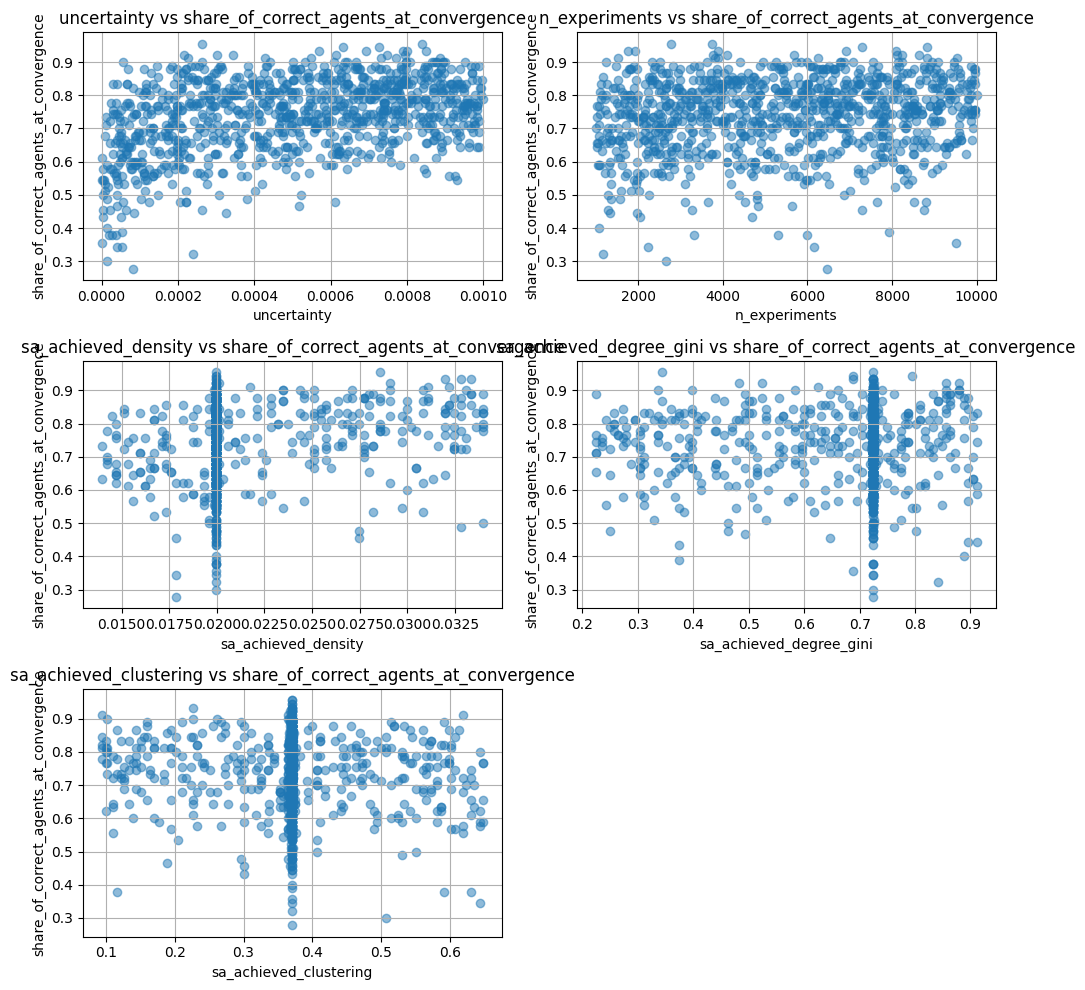

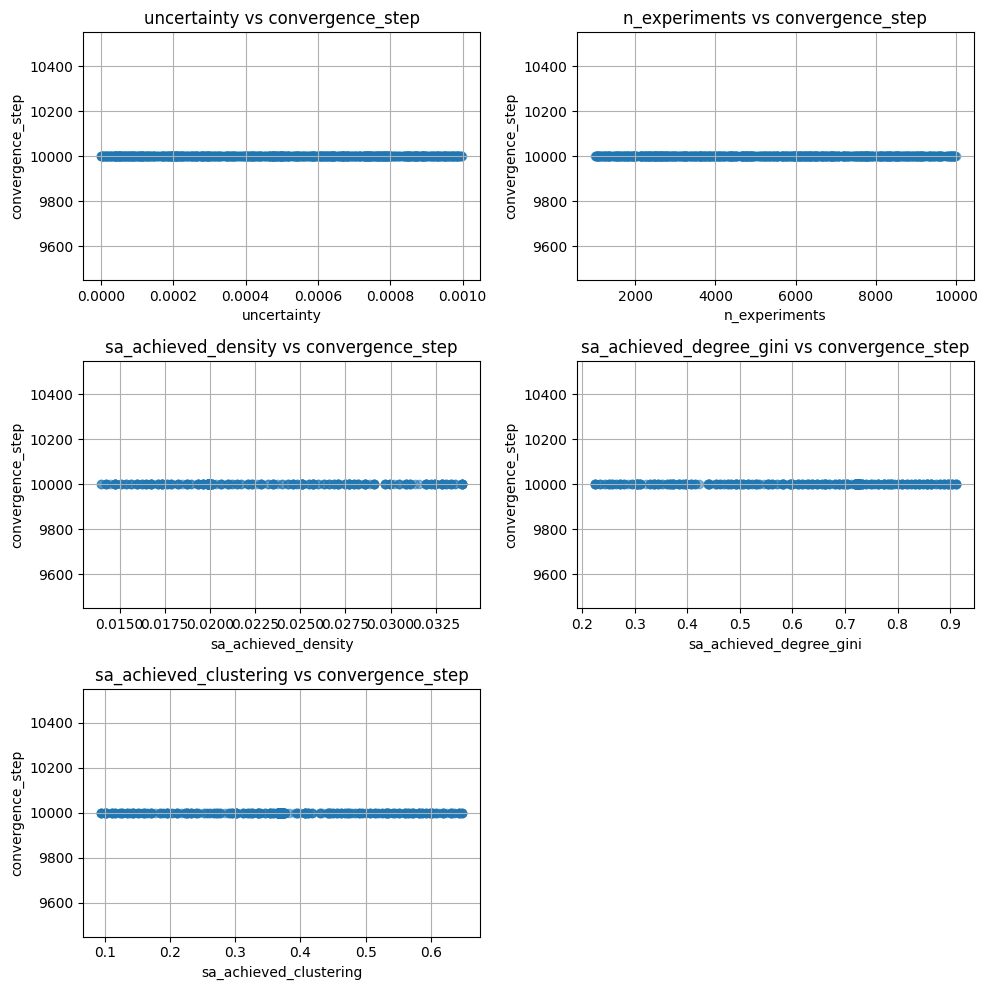

,randomized,unique_id,network_type,source_id,network_path,uncertainty,n_experiments,parameter_random_seed,sa_source_id,sa_source_path,...,sa_preserve_error_scaled_density,degree_gini_coefficient,approx_average_clustering_coefficient,average_degree,n_agents,share_of_correct_agents_at_convergence,share_of_core_agents_at_convergence,convergence_step,proportion_reached_by_truth,agent_choice_variance_history
0,True,b422e936a7574738bf76841e2687bf25,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000292,1541,4105194777,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.695417,0.370370,1.777778,90,0.666667,0.804878,10000,0.666667,"[0.25, 0.24950617283950619, 0.2488888888888888..."
1,True,44efebbd88e940d7953a28fc86f10b6f,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000421,2602,2313148603,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,NaN,0.725090,0.370253,2.066667,90,0.800000,0.936170,10000,0.777778,"[0.24888888888888888, 0.20543209876543217, 0.2..."
2,True,71704cab3a054c209cf8f193503d1113,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000135,1679,1370426967,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.637639,0.370130,1.777778,90,0.555556,0.575000,10000,0.644444,"[0.24888888888888888, 0.24987654320987648, 0.2..."
3,True,c69773b2f8fd487889677096ea99a7db,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000108,6647,3240049370,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,NaN,0.724224,0.370262,2.466667,90,0.722222,0.854545,10000,0.566667,"[0.25, 0.24000000000000002, 0.2439506172839505..."
4,True,3c10e0bfdd664c259bd49b1b1e1802e2,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000556,3281,3593505299,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.595278,0.370242,1.777778,90,0.722222,0.883721,10000,0.633333,"[0.24691358024691362, 0.24987654320987648, 0.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,True,7c4b94fe16a849678a3f8691cfb8e6c3,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000338,3930,82376768,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.724583,0.591912,1.777778,90,0.766667,0.894737,10000,0.711111,"[0.24395061728395054, 0.24987654320987648, 0.2..."
996,True,f4954dba03a64c6f838d5e749e8221f1,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000676,9345,2581051358,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.724583,0.184375,1.777778,90,0.811111,0.925000,10000,0.755556,"[0.24691358024691365, 0.2376543209876543, 0.21..."
997,True,9d5777858b4b4819b2b8ebf3e5e21ae5,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000050,6065,1684084700,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.441806,0.370107,1.777778,90,0.677778,0.800000,10000,0.733333,"[0.24950617283950619, 0.2420987654320987, 0.24..."
998,True,3fa9fd737d2141579a9ca2b395d903e8,pud,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000774,2987,1051594127,pud_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.724583,0.607843,1.777778,90,0.844444,0.947368,10000,0.844444,"[0.24802469135802468, 0.24987654320987648, 0.2..."


In [9]:
plot_network_type_results(
    'pud',
    dumping_path=dumping_path,
    results_name='pud',
    plot_variables=PLOT_VARIABLES,
    target_variables=PLOT_TARGET_VARIABLES,
)


In [10]:
# scatter_plot(combined_results_df)

In [11]:
# scatter_plot(combined_results_df, target_variable="convergence_step")

# Testing Tobacco

In [12]:
network_type = 'tobacco'

num_cores = cpu_count()
print(f'Using {num_cores} cores')
if has_sa_network_pool(network_type, **SA_NETWORK_KWARGS):
    describe_sa_network_pool(network_type, **SA_NETWORK_KWARGS)
else:
    print(f'No SA graph pool found for {network_type!r}. Available saved source ids: {available_sa_network_types(**SA_NETWORK_KWARGS)}')


Using 16 cores
'tobacco' -> 'tobacco_network'
289 saved graphs available


In [13]:
n_simulations = n_simulations
if has_sa_network_pool('tobacco', **SA_NETWORK_KWARGS):
    run_network_type(
        'tobacco',
        dumping_path=dumping_path,
        num_cores=num_cores,
        n_simulations=n_simulations,
        results_name='tobacco',
        simulation_kwargs=VECTOR_SIMULATION_KWARGS,
        parameter_generation_settings=PARAMETER_GENERATION_SETTINGS,
        **SA_NETWORK_KWARGS,
    )
else:
    print(f'Skipping tobacco: no SA graph pool found. Available saved source ids: {available_sa_network_types(**SA_NETWORK_KWARGS)}')


Running simulations for network_type='tobacco'
Generating parameters...


Generating parameters:   0%|          | 0/1000 [00:00<?, ?it/s]

Running simulations:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved 1,000 rows to results/SA_approach_run_v8_10k_steps_trajectories/tobacco_results_sa.csv


## Basic Plotting Tobacco

1000


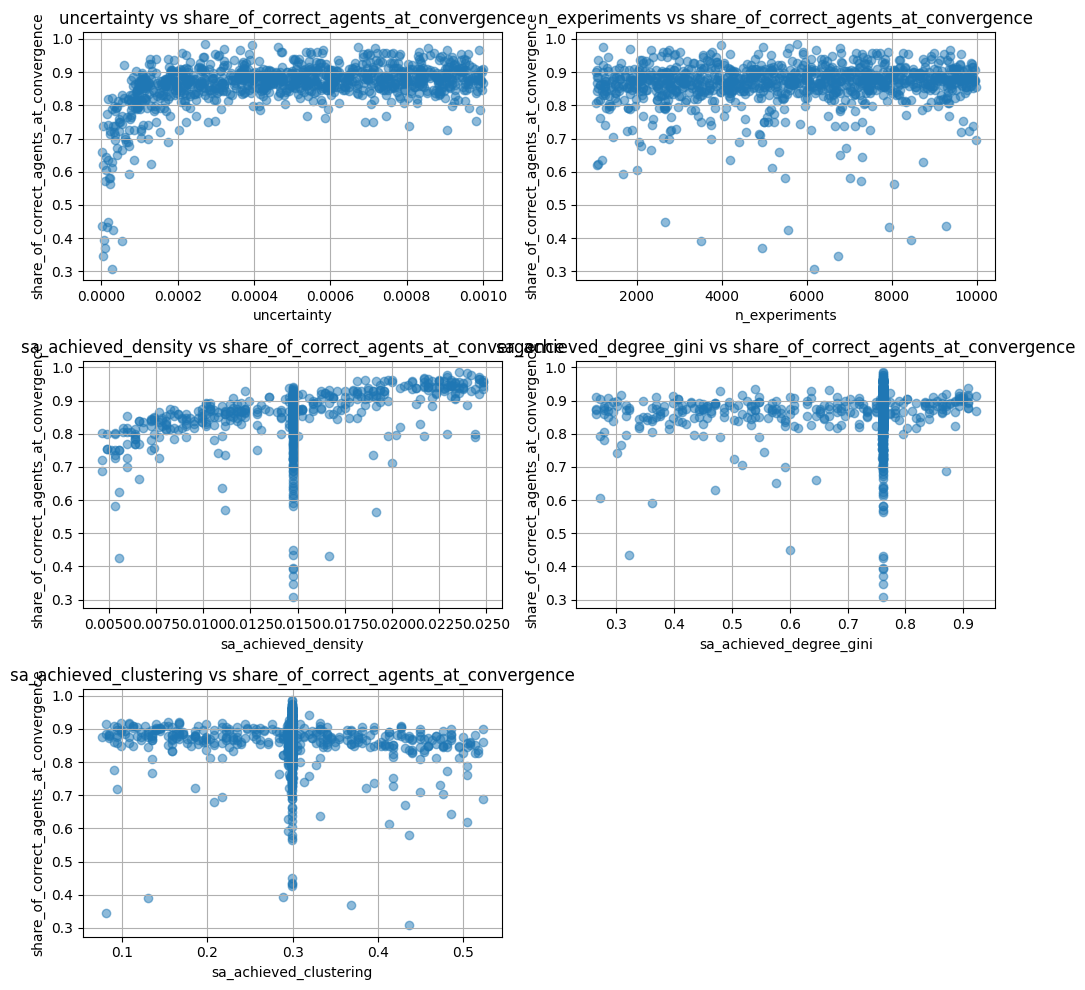

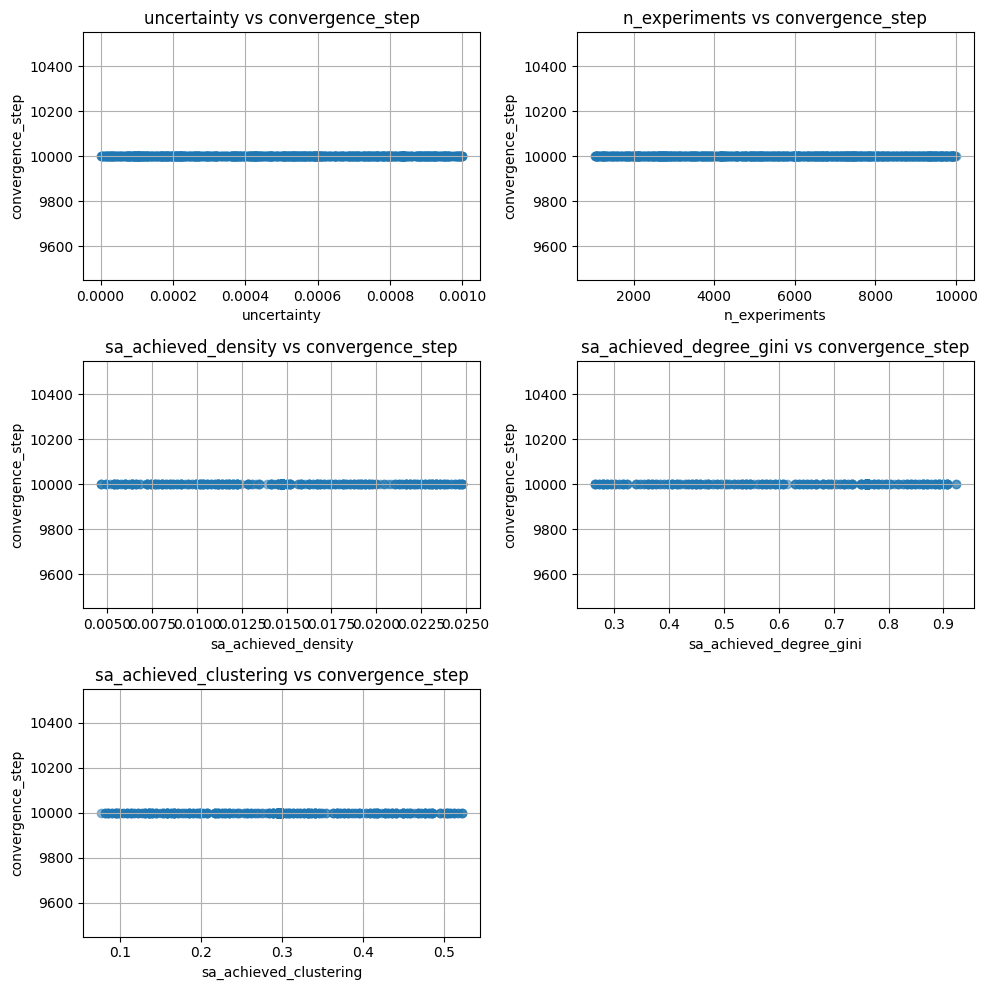

In [14]:
if results_path_for_network_type(dumping_path, 'tobacco', results_name='tobacco').exists():
    plot_network_type_results(
        'tobacco',
        dumping_path=dumping_path,
        results_name='tobacco',
        plot_variables=PLOT_VARIABLES,
        target_variables=PLOT_TARGET_VARIABLES,
    )
else:
    print('No tobacco SA results file found yet.')


## Testing Ego Depletion


In [15]:
network_type = 'ego_depletion'

num_cores = cpu_count()
print(f'Using {num_cores} cores')
describe_sa_network_pool(network_type, **SA_NETWORK_KWARGS)


Using 16 cores
'ego_depletion' -> 'ego_network'
263 saved graphs available


,source_id,target_stat,n_graphs
0,ego_network,clustering,68
1,ego_network,degree_gini,95
2,ego_network,density,100


In [16]:
n_simulations = n_simulations
run_network_type(
    'ego_depletion',
    dumping_path=dumping_path,
    num_cores=num_cores,
    n_simulations=n_simulations,
    results_name='ego_depletion',
    simulation_kwargs=VECTOR_SIMULATION_KWARGS,
    parameter_generation_settings=PARAMETER_GENERATION_SETTINGS,
    **SA_NETWORK_KWARGS,
)


Running simulations for network_type='ego_depletion'
Generating parameters...


Generating parameters:   0%|          | 0/1000 [00:00<?, ?it/s]

Running simulations:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved 1,000 rows to results/SA_approach_run_v8_10k_steps_trajectories/ego_depletion_results_sa.csv


,randomized,unique_id,network_type,source_id,network_path,uncertainty,n_experiments,parameter_random_seed,sa_source_id,sa_source_path,...,sa_preserve_error_scaled_density,degree_gini_coefficient,approx_average_clustering_coefficient,average_degree,n_agents,share_of_correct_agents_at_convergence,share_of_core_agents_at_convergence,convergence_step,proportion_reached_by_truth,agent_choice_variance_history
0,True,76033faf2b0c49fb88cb3ba52b415a04,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000305,7148,2408795131,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.691892,0.421708,5.831014,503,0.996024,1.000000,10000,0.000000,"[0.24999901189285756, 0.24108233303953613, 0.2..."
1,True,6ba3b6e449eb408c967d503cbfcd2d0e,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000294,7909,1634045553,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,NaN,0.920472,0.421767,3.512922,503,0.994036,1.000000,10000,0.994036,"[0.24964329332158153, 0.1926097490603101, 0.21..."
2,True,4e0665f3d28e4498b9d2a658d2310e30,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000207,8554,2739198546,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.920430,0.350591,5.831014,503,0.996024,0.997696,10000,1.000000,"[0.24971443703583662, 0.19165326134643432, 0.2..."
3,True,6ae1f2f1380544e48c80261a0216989b,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000842,1309,1358418935,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.920430,0.401118,5.831014,503,0.996024,1.000000,10000,0.000000,"[0.24999110703571809, 0.20347102276994103, 0.1..."
4,True,412cb4eab2b4454ea447a28434fc66a3,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000791,9834,1793088746,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.920430,0.229148,5.831014,503,1.000000,1.000000,10000,1.000000,"[0.24999110703571809, 0.11979810994865797, 0.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,True,6ceccbfdc913404fb42d731dab667e27,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000068,2743,1305024730,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.627610,0.421706,5.831014,503,0.840954,0.844907,10000,0.000000,"[0.24905042903612132, 0.24999901189285764, 0.2..."
996,True,3aabbd653752407bb47e1a74da1e0b7b,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000678,7418,3693681377,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,NaN,0.920408,0.421692,8.395626,503,0.996024,1.000000,10000,0.000000,"[0.24995158275002072, 0.21165254990929178, 0.2..."
997,True,bd67a253a7284b0bb110bfdb778cbb22,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000256,6366,465199536,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.902673,0.421689,5.831014,503,0.998012,1.000000,10000,0.000000,"[0.2498330098929287, 0.2495642447501867, 0.235..."
998,True,f2d7aff9bf1e42cfaec63624f851aa42,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000945,5881,2820083532,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.920430,0.120633,5.831014,503,1.000000,1.000000,10000,1.000000,"[0.24977767589295236, 0.18774826191953647, 0.1..."


1000


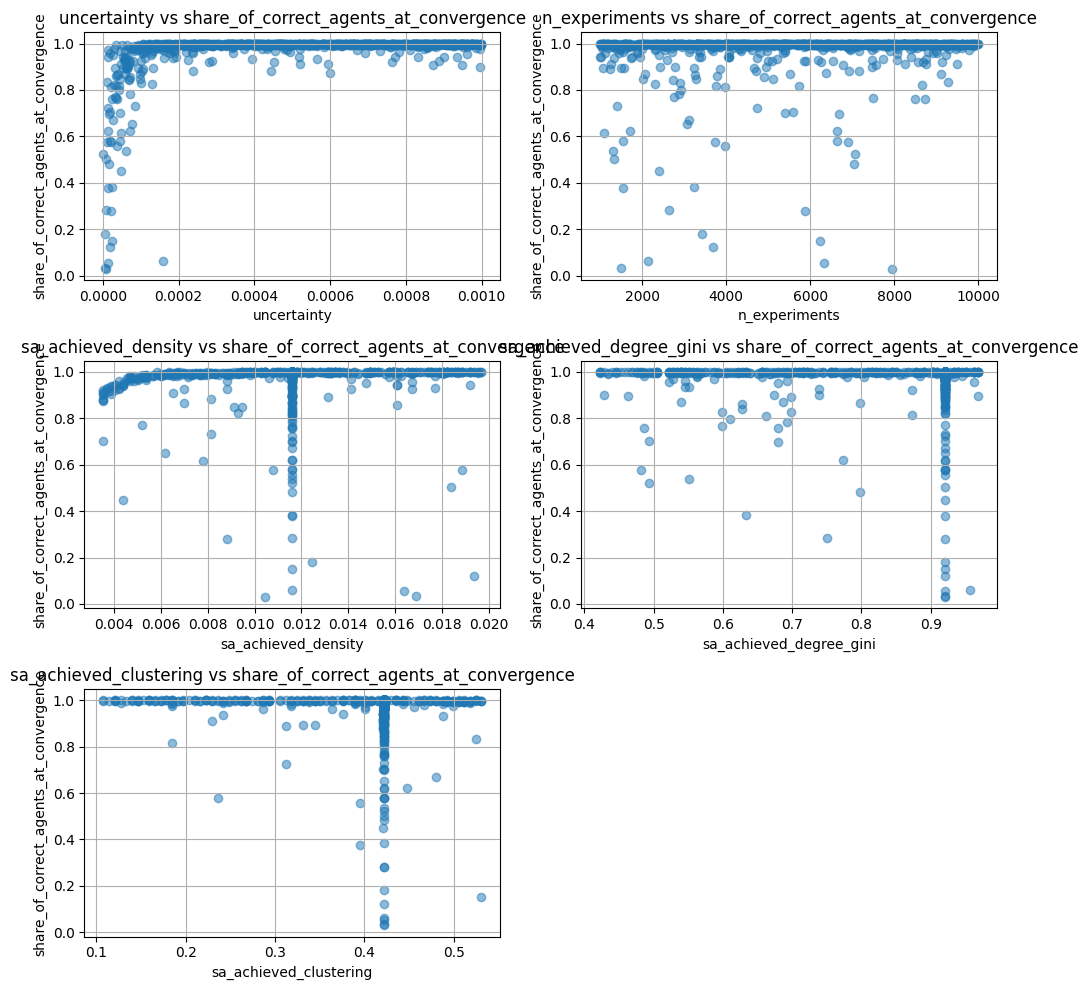

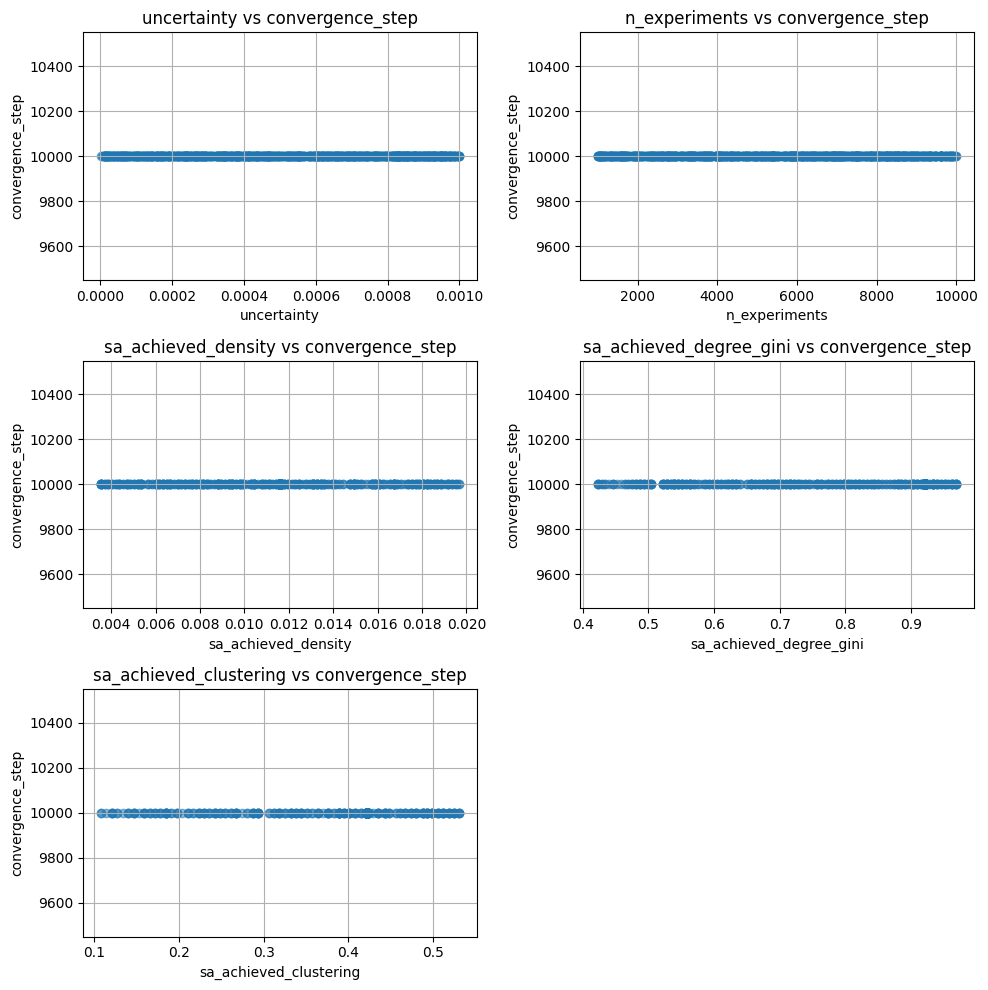

,randomized,unique_id,network_type,source_id,network_path,uncertainty,n_experiments,parameter_random_seed,sa_source_id,sa_source_path,...,sa_preserve_error_scaled_density,degree_gini_coefficient,approx_average_clustering_coefficient,average_degree,n_agents,share_of_correct_agents_at_convergence,share_of_core_agents_at_convergence,convergence_step,proportion_reached_by_truth,agent_choice_variance_history
0,True,76033faf2b0c49fb88cb3ba52b415a04,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000305,7148,2408795131,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.691892,0.421708,5.831014,503,0.996024,1.000000,10000,0.000000,"[0.24999901189285756, 0.24108233303953613, 0.2..."
1,True,6ba3b6e449eb408c967d503cbfcd2d0e,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000294,7909,1634045553,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,NaN,0.920472,0.421767,3.512922,503,0.994036,1.000000,10000,0.994036,"[0.24964329332158153, 0.1926097490603101, 0.21..."
2,True,4e0665f3d28e4498b9d2a658d2310e30,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000207,8554,2739198546,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.920430,0.350591,5.831014,503,0.996024,0.997696,10000,1.000000,"[0.24971443703583662, 0.19165326134643432, 0.2..."
3,True,6ae1f2f1380544e48c80261a0216989b,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000842,1309,1358418935,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.920430,0.401118,5.831014,503,0.996024,1.000000,10000,0.000000,"[0.24999110703571809, 0.20347102276994103, 0.1..."
4,True,412cb4eab2b4454ea447a28434fc66a3,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000791,9834,1793088746,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.920430,0.229148,5.831014,503,1.000000,1.000000,10000,1.000000,"[0.24999110703571809, 0.11979810994865797, 0.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,True,6ceccbfdc913404fb42d731dab667e27,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000068,2743,1305024730,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.627610,0.421706,5.831014,503,0.840954,0.844907,10000,0.000000,"[0.24905042903612132, 0.24999901189285764, 0.2..."
996,True,3aabbd653752407bb47e1a74da1e0b7b,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000678,7418,3693681377,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,NaN,0.920408,0.421692,8.395626,503,0.996024,1.000000,10000,0.000000,"[0.24995158275002072, 0.21165254990929178, 0.2..."
997,True,bd67a253a7284b0bb110bfdb778cbb22,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000256,6366,465199536,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.902673,0.421689,5.831014,503,0.998012,1.000000,10000,0.000000,"[0.2498330098929287, 0.2495642447501867, 0.235..."
998,True,f2d7aff9bf1e42cfaec63624f851aa42,ego_depletion,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,0.000945,5881,2820083532,ego_network,/Users/Noich001/Desktop/network_inequality_cur...,...,0.0,0.920430,0.120633,5.831014,503,1.000000,1.000000,10000,1.000000,"[0.24977767589295236, 0.18774826191953647, 0.1..."


In [17]:
plot_network_type_results(
    'ego_depletion',
    dumping_path=dumping_path,
    results_name='ego_depletion',
    plot_variables=PLOT_VARIABLES,
    target_variables=PLOT_TARGET_VARIABLES,
)


## Disconnect from Runtime

In [18]:
# from datetime import datetime
# import pytz
# from IPython.display import Javascript

# # Get current time in New York
# nyc_time = datetime.now(pytz.timezone('America/New_York'))
# formatted_time = nyc_time.strftime('%Y-%m-%d %H:%M:%S %Z')

# # Print and log
# print(f"✅ Disconnected from runtime at: {formatted_time}")

# # Disconnect Colab runtime
# display(Javascript('google.colab.kernel.disconnect()'))